In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
# Load the dataset

In [2]:

df = pd.read_csv('./steel_fault.csv')


df.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V25,V26,V27,V28,V29,V30,V31,V32,V33,Class
0,42,50,270900,270944,267,17,44,24220,76,108,...,0.8182,-0.2913,0.5822,1,0,0,0,0,0,1
1,645,651,2538079,2538108,108,10,30,11397,84,123,...,0.7931,-0.1756,0.2984,1,0,0,0,0,0,1
2,829,835,1553913,1553931,71,8,19,7972,99,125,...,0.6667,-0.1228,0.2150,1,0,0,0,0,0,1
3,853,860,369370,369415,176,13,45,18996,99,126,...,0.8444,-0.1568,0.5212,1,0,0,0,0,0,1
4,1289,1306,498078,498335,2409,60,260,246930,37,126,...,0.9338,-0.1992,1.0000,1,0,0,0,0,0,1


In [3]:
print(df.columns)

Index(['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11',
       'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21',
       'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'V29', 'V30', 'V31',
       'V32', 'V33', 'Class'],
      dtype='object')


In [4]:
import seaborn as sns
import matplotlib.pyplot as plt


Text(0.5, 1.0, 'Correlation Heatmap')

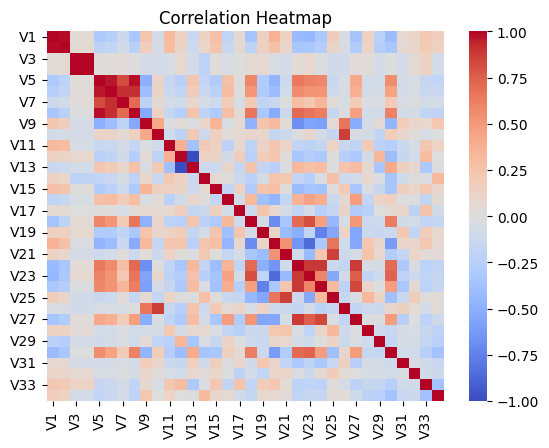

In [6]:
sns.heatmap(df.corr(), cmap='coolwarm')
plt.title('Correlation Heatmap')

In [7]:
# TODO: calculate vif for each feature and drop features

In [8]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler




In [12]:
pca = PCA(n_components=33)
pca.fit(df)
pca.explained_variance_

array([6.29831358e+12, 2.62455437e+11, 1.26593018e+06, 4.62372825e+05,
       1.88647800e+04, 1.38334556e+04, 2.79879672e+03, 2.57936895e+03,
       7.52990170e+02, 6.86874125e+02, 1.53213334e+02, 6.32226160e+01,
       5.42336571e-01, 3.58206969e-01, 2.60732146e-01, 2.31644015e-01,
       1.31509904e-01, 7.37752573e-02, 6.37356588e-02, 5.47823028e-02,
       4.39564972e-02, 3.82999156e-02, 2.94621463e-02, 2.24402265e-02,
       1.42024494e-02, 1.12454355e-02, 8.63246211e-03, 4.54627506e-03,
       2.09772141e-03, 1.60093118e-03, 1.34416504e-04, 9.85878465e-05,
       2.38146406e-17])

In [14]:
pca.explained_variance_ratio_

array([9.59995980e-01, 4.00037504e-02, 1.92954489e-07, 7.04753816e-08,
       2.87539080e-09, 2.10851073e-09, 4.26595718e-10, 3.93150292e-10,
       1.14771602e-10, 1.04694120e-10, 2.33529472e-11, 9.63646165e-12,
       8.26635451e-14, 5.45983057e-14, 3.97410846e-14, 3.53074391e-14,
       2.00448862e-14, 1.12449070e-14, 9.71466020e-15, 8.34997969e-15,
       6.69989832e-15, 5.83771586e-15, 4.49065319e-15, 3.42036434e-15,
       2.16475318e-15, 1.71404182e-15, 1.31576950e-15, 6.92948314e-16,
       3.19737037e-16, 2.44015716e-16, 2.04879135e-17, 1.50268695e-17,
       3.62985407e-30])

In [30]:
transformed_df = pca.transform(df)

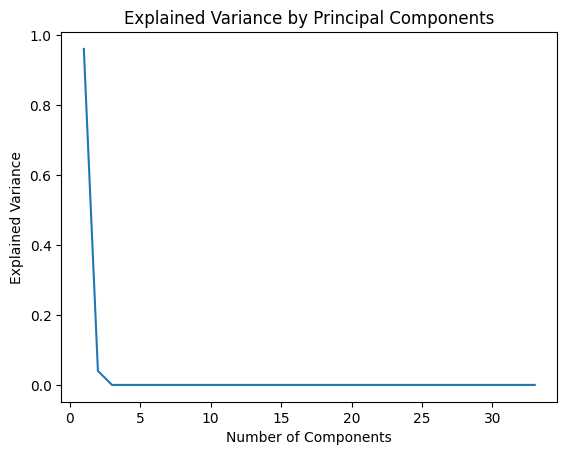

In [19]:
plt.plot(range(1, 34), pca.explained_variance_ratio_)
plt.xlabel('Number of Components')
plt.ylabel('Explained Variance')
plt.title('Explained Variance by Principal Components')
plt.show()

In [22]:
df.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V25,V26,V27,V28,V29,V30,V31,V32,V33,Class
0,42,50,270900,270944,267,17,44,24220,76,108,...,0.8182,-0.2913,0.5822,1,0,0,0,0,0,1
1,645,651,2538079,2538108,108,10,30,11397,84,123,...,0.7931,-0.1756,0.2984,1,0,0,0,0,0,1
2,829,835,1553913,1553931,71,8,19,7972,99,125,...,0.6667,-0.1228,0.2150,1,0,0,0,0,0,1
3,853,860,369370,369415,176,13,45,18996,99,126,...,0.8444,-0.1568,0.5212,1,0,0,0,0,0,1
4,1289,1306,498078,498335,2409,60,260,246930,37,126,...,0.9338,-0.1992,1.0000,1,0,0,0,0,0,1


In [35]:
# logestic regression model without pca
# score using precession, recall, auc, f1 score


from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, precision_score, recall_score, f1_score


print(df['Class'].value_counts())

y = df['Class']
X = df.drop('Class', axis=1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = LogisticRegression()
model.fit(X_train, y_train)
# print(model.score(X_test, y_test))


print('Classification Report: for train data\n', classification_report(y_train, model.predict(X_train)))

print('Classification Report: for test data\n', classification_report(y_test, model.predict(X_test)))


Class
1    1268
2     673
Name: count, dtype: int64
Classification Report: for train data
               precision    recall  f1-score   support

           1       0.68      0.95      0.79      1022
           2       0.56      0.13      0.21       530

    accuracy                           0.67      1552
   macro avg       0.62      0.54      0.50      1552
weighted avg       0.64      0.67      0.59      1552

Classification Report: for test data
               precision    recall  f1-score   support

           1       0.65      0.96      0.78       246
           2       0.62      0.13      0.21       143

    accuracy                           0.65       389
   macro avg       0.64      0.54      0.49       389
weighted avg       0.64      0.65      0.57       389



C:\Users\ashwi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [38]:
# # logestic regression model with pca
# # score using precession, recall, auc, f1 score


# from sklearn.linear_model import LogisticRegression
# from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, precision_score, recall_score, f1_score



# pca = PCA(n_components=33)
# pca.fit(X)
# print(pca.explained_variance_ratio_)
# X = pca.transform(X)



# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# model = LogisticRegression()
# model.fit(X_train, y_train)
# # print(model.score(X_test, y_test))


# print('Classification Report: for train data\n', classification_report(y_train, model.predict(X_train)))

# print('Classification Report: for test data\n', classification_report(y_test, model.predict(X_test)))


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler  # <-- Crucial addition
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

# 1. Split features and target
y = df['Class']
X = df.drop('Class', axis=1)

# 2. Split into Train and Test FIRST to prevent leakage
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Scale your data (Fit on Train, Transform both)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. Apply PCA (Fit on Train, Transform both)
pca = PCA(n_components=33)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print("Explained Variance Ratio:\n", pca.explained_variance_ratio_)

# 5. Train and Evaluate your model
model = LogisticRegression(max_iter=1000)
model.fit(X_train_pca, y_train)

print('\nClassification Report: for test data\n', classification_report(y_test, model.predict(X_test_pca)))


Explained Variance Ratio:
 [2.72450357e-01 1.11756039e-01 8.79821078e-02 7.26258244e-02
 6.62605984e-02 5.56867715e-02 4.74673062e-02 4.06241479e-02
 3.44400978e-02 2.96693890e-02 2.74671550e-02 2.36959991e-02
 2.14310328e-02 1.88655266e-02 1.69884391e-02 1.48969333e-02
 1.22972525e-02 1.06148449e-02 8.40254825e-03 7.39305002e-03
 6.23565130e-03 5.30061137e-03 2.77744218e-03 1.63965606e-03
 1.38423177e-03 1.06832711e-03 3.40787375e-04 1.84921804e-04
 3.64603664e-05 1.60901887e-05 3.98819958e-07 9.81047577e-13
 0.00000000e+00]

Classification Report: for test data
               precision    recall  f1-score   support

           1       1.00      1.00      1.00       246
           2       1.00      1.00      1.00       143

    accuracy                           1.00       389
   macro avg       1.00      1.00      1.00       389
weighted avg       1.00      1.00      1.00       389



# report of 1 is overfitting
- no model gives 100% accuracy



# uses of PCA
- mulitcolleanirity reduction
- dimeantianatiolity reductions
- visulaition of data using lesser dimentions

In [39]:
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler  # <-- Crucial addition
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

# 1. Split features and target
y = df['Class']
X = df.drop('Class', axis=1)

# 2. Split into Train and Test FIRST to prevent leakage
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Scale your data (Fit on Train, Transform both)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. Apply PCA (Fit on Train, Transform both)
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print("Explained Variance Ratio:\n", pca.explained_variance_ratio_)

# 5. Train and Evaluate your model
model = LogisticRegression(max_iter=1000)
model.fit(X_train_pca, y_train)

print('\nClassification Report: for test data\n', classification_report(y_test, model.predict(X_test_pca)))


Explained Variance Ratio:
 [0.27245036 0.11175604]

Classification Report: for test data
               precision    recall  f1-score   support

           1       0.63      1.00      0.77       246
           2       0.00      0.00      0.00       143

    accuracy                           0.63       389
   macro avg       0.32      0.50      0.39       389
weighted avg       0.40      0.63      0.49       389



C:\Users\ashwi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\ashwi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\ashwi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\metrics\_classificati

<Axes: >

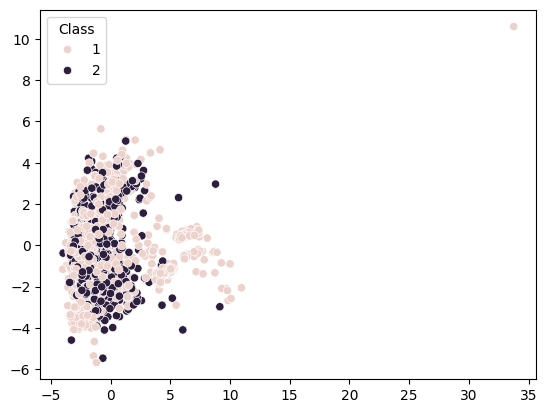

In [43]:
sns.scatterplot(x=X_train_pca[:, 0], y=X_train_pca[:, 1], hue=y_train)